# Direct Detection

In [1]:
# Library imports and params
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import interpolate

# Defining the fonts before plotting:

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "monospace",  # Use monospace font
    "text.latex.preamble": r"\usepackage{courier}"  # Use Courier font
})
mpl.rcParams.update(mpl.rcParamsDefault)

plt.rcParams.update({
    'font.family': 'monospace',  # monospace font
    "text.latex.preamble": r"\usepackage{courier}",
    'font.size': 25,
    'axes.titlesize': 25,
    'axes.labelsize': 25,
    'xtick.labelsize': 25,
    'ytick.labelsize': 25,
    'legend.fontsize': 25,
    'figure.titlesize': 25,
})


In [2]:
### Constants and fixed parameters, carried over from Relic_Abundance.ipynb.

alpha = 1/137
alphaD = 0.1

mchi_over_ma = 0.6

OmegaDM = 0.265        # without the reduced Hubble constant factor

mp = 0.93827208816     # proton mass in GeV
me = 0.51099895e-3     # electron mass in GeV

### A xenon nucleus, and the momentum transfer a xenon recoil actually
### carries: q = sqrt(2 m_Xe E_R) at E_R = 10 keV, the middle of the search
### window, is 49 MeV. The mediator propagator can only be replaced by
### 1/m_A'^4 while m_A' is well above that.

mXe = 122.30           # 131 Xe nucleus mass in GeV
ER_ref = 1e-5          # reference nuclear recoil energy, 10 keV
q_ref_n = np.sqrt(2*mXe*ER_ref)

### For electron recoils the momentum transfer is set by the bound electron
### wavefunction instead, q ~ alpha m_e = 3.7 keV, which is negligible
### against every mediator mass considered here.

q_ref_e = alpha*me

cm2_to_GeVm2 = 2.5681894616e27          # 1 cm^2 = (hbar c)^-2 GeV^-2

### The direct detection limits are algebraic, so they get their own dense
### grid rather than the relic line's; it runs well past the relic file
### because XENONnT and LZ only constrain mchi >= 3 and 9 GeV, i.e.
### m_A' >= 5 and 15 GeV at this mass ratio.

ma_dd = np.logspace(np.log10(1e-2), np.log10(1e2), 4000)
mchi_dd = mchi_over_ma*ma_dd


In [3]:
### The relic line from moller_scan.py: the Gondolo-Gelmini thermal average
### solved for the epsilon that reproduces Omega_DM, cached so this notebook
### never has to re-run the scan.

def read_relic_csv(path):
    """Read a moller_scan.py CSV, returning (ma, eps, metadata dict)."""
    meta = {}
    with open(path) as fh:
        for line in fh:
            if not line.startswith("#"):
                break
            for field in line.lstrip("# ").split(","):
                if "=" in field:
                    key, val = field.split("=", 1)
                    meta[key.strip()] = val.strip()

    # np.genfromtxt takes the first line as the names even when it is a
    # comment, so the three header comments have to be skipped explicitly.
    data = np.genfromtxt(path, delimiter=",", names=True, skip_header=3)
    return data["MAp"], data["eps"], meta

### Kling's mass range, the file the scan was written for.

ma_relic, eps_relic, meta_relic = read_relic_csv("data/moller_relic_line.csv")

### The same scan carried out to 20 GeV, which is where the direct detection
### limits live; the two agree point for point where they overlap.

ma_relic_w, eps_relic_w, meta_relic_w = read_relic_csv(
    "data/moller_relic_line_wide.csv")

alphaD = float(meta_relic["alphaD"])
mchi_over_ma = float(meta_relic["mchi_over_ma"])
mchi_dd = mchi_over_ma*ma_dd


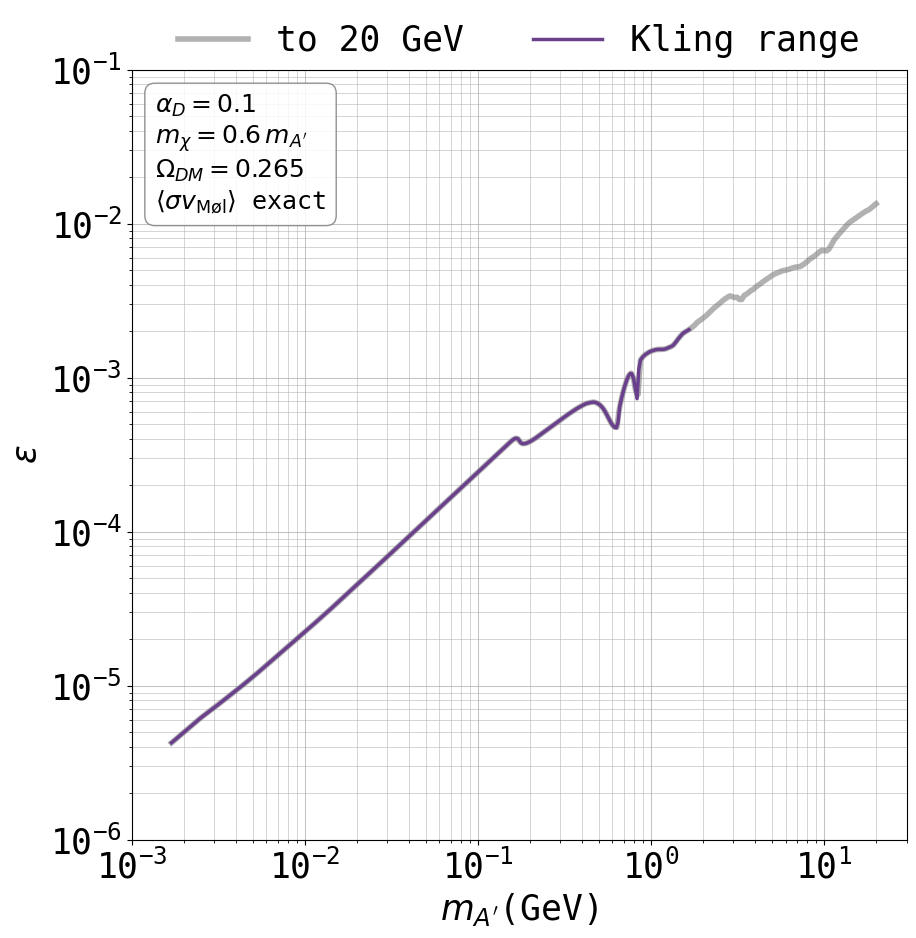

In [4]:
### Confirming the imported line before anything is built on top of it.

# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

# Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

# Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

# Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

ax.plot(ma_relic_w, eps_relic_w, color = '#7e7e7e', linewidth = 4.0,
        alpha = 0.6, label = r"to 20 GeV")
ax.plot(ma_relic, eps_relic, color = '#6a408d', linewidth = 2.5,
        label = r"Kling range")

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % alphaD,
                   r"$m_\chi = %g\, m_{A'}$" % mchi_over_ma,
                   r"$\Omega_{DM} = %s$" % meta_relic["Omega_target"],
                   r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ exact"]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 2,                      # spread horizontally
    frameon = False                # removes legend border
)

ax.set_xbound(1e-3, 3e1)
ax.set_ybound(1e-6, 1e-1)

# Save and show the figure:
plt.savefig("figures/relic_line_moller_imported.pdf", bbox_inches='tight')
plt.show()


In [5]:
data_LZ_2024 = np.loadtxt("data/LZ2024_Limit.csv", delimiter=',')

mass_data_LZ_2024 = data_LZ_2024[:, 0]
sigmasidatacm2_LZ_2024 = data_LZ_2024[:, 1]

cm2_to_GeVm2 = 2.5681894616e27          # 1 cm^2 = (hbar c)^-2 GeV^-2
sigmasidataGeV_LZ_2024 = sigmasidatacm2_LZ_2024 * cm2_to_GeVm2

# Interpolating
dd_limit_fun_LZ2024 = interpolate.interp1d(mass_data_LZ_2024, sigmasidataGeV_LZ_2024)

In [6]:
### The theory side: the cross sections an experiment's limit is compared
### against. All three are the same dark photon exchange amplitude, differing
### only in the target and in how the propagator is treated.

def sig_si_theo(ma, alpha, alphaD, mchi, epsilon):
    """SI DM-nucleon cross section in the heavy mediator limit, in GeV^-2."""
    mu = mchi*mp/(mchi + mp)                                   # reduced mass
    return 16*np.pi * epsilon**2 * alpha * alphaD * mu**2 / ma**4

def sig_si_theo_ff(ma, alpha, alphaD, mchi, epsilon, q = None):
    """SI DM-nucleon cross section keeping the mediator propagator at finite q.

    The dark matter form factor F_DM(q) = m_A'^2/(m_A'^2 + q^2) multiplies the
    amplitude, so the cross section carries its square. It reduces to
    sig_si_theo for m_A' >> q and cuts the rate off as (m_A'/q)^4 below it.
    """
    q = q_ref_n if q is None else q
    mu = mchi*mp/(mchi + mp)                                   # reduced mass
    return (16*np.pi * epsilon**2 * alpha * alphaD * mu**2
            / (ma**2 + q**2)**2)

def sig_si_theo_elec(ma, alpha, alphaD, mchi, epsilon, q = None):
    """DM-electron cross section at the reference momentum transfer, GeV^-2.

    Same amplitude with the electron as the target, so only the reduced mass
    changes; q = alpha m_e is small enough that the propagator is effectively
    the heavy mediator one over the whole mass range plotted here.
    """
    q = q_ref_e if q is None else q
    mu = mchi*me/(mchi + me)                                   # reduced mass
    return (16*np.pi * epsilon**2 * alpha * alphaD * mu**2
            / (ma**2 + q**2)**2)

### One helper instead of a per-experiment copy: every limit is the same
### comparison, sigma_theo(epsilon = 1) against a tabulated sigma.

def eps_dd_limit(ma, mchi, mass_tab, sigma_tab, sigma_theo = sig_si_theo,
                 alpha = alpha, alphaD = alphaD):
    """epsilon at which sigma_theo equals the tabulated limit at that mchi.

    Points whose mchi falls outside the tabulated mass range are dropped, so
    the limit is only drawn where the experiment actually constrains it.

    Returns (ma_valid, eps_valid).
    """
    ma, mchi = np.broadcast_arrays(np.atleast_1d(ma), np.atleast_1d(mchi))

    # Keep only the points the interpolator can evaluate:
    inside = (mchi >= mass_tab.min()) & (mchi <= mass_tab.max())
    ma, mchi = ma[inside], mchi[inside]

    # The tabulated limits span decades over few points, so they are read
    # off a log-log interpolation; a linear one overshoots between them.
    sigma_lim = np.exp(np.interp(np.log(mchi), np.log(mass_tab),
                                 np.log(sigma_tab)))
    return ma, np.sqrt(sigma_lim / sigma_theo(ma, alpha, alphaD, mchi, 1.0))

def eps_dd_limit_LZ2024(ma, alpha, alphaD, mchi):
    """epsilon at which sig_si_theo == the LZ 2024 limit at that mchi."""
    return eps_dd_limit(ma, mchi, mass_data_LZ_2024, sigmasidataGeV_LZ_2024,
                        alpha = alpha, alphaD = alphaD)


In [7]:
mlims, eplims =eps_dd_limit_LZ2024(ma_dd, alpha, alphaD, mchi_dd)

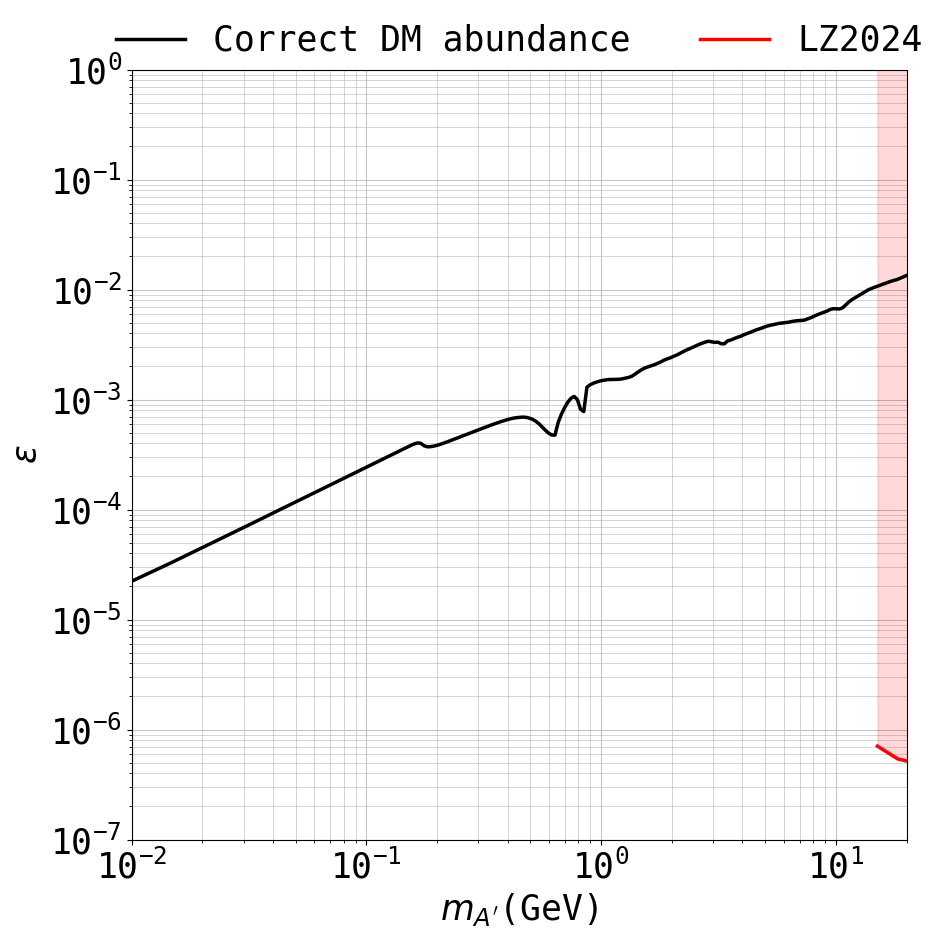

In [8]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Lock the square shape
#ax.set_aspect('equal', adjustable='datalim')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

ax.plot(ma_relic_w, eps_relic_w, color = 'black', linewidth = 2.5,
        label = r"Correct DM abundance")

ax.plot(mlims, eplims, color = 'red', linewidth = 2.5, label = r"LZ2024")

ax.fill_between(mlims, eplims, 
                1,
                label= rf"Direct detection (Xenon1T)",
                color='red', 
                alpha=0.15, 
                zorder=1)

## Color palets:

dataset_colors = ['#9671bd', '#7e7e7e', '#77b5b6']
dataset_line_colors = ['#6a408d', '#4e4e4e', '#378d94']

# And the colour for the lines (regressions):
regression_color = '#8a8a8a' # <-- neutral grey
# regression_color = '#7f9fa1' # <-- greyish seafoam

'''

ax.scatter(final_data[:,0],final_data[:,1],
            label = "Correct DM abundance",
          s = 90,
          color = dataset_colors[0],
          edgecolors = dataset_line_colors[0],
          linewidths = 1.5,
          zorder = 3
    )

'''

## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0,1]  # change the order of legend elements


ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 2e1
x_range = x_max - x_min

y_min = 1e-7
y_max = 1e0
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)


# Save and show the figure:
plt.savefig("figures/relic_abundance_0.pdf", bbox_inches='tight')
plt.show()

In [9]:
### XENONnT SR0+1 SI limit (FIG 3 A of arXiv:2409.17868), from the .npy points

limits_dir_XENONnT = ("data/XENONnT-light_wimp_data_release-64d2e13/"
                      "light_wimp_data_release/limits")

# The published limit is the power-constrained one; the folder also holds
# xenonnt_si_limit_before_pcl.npy and xenonnt_si_limit_after_dl_pcl.npy.
data_XENONnT_si = np.load(f"{limits_dir_XENONnT}/xenonnt_si_limit_after_pcl.npy")

mass_data_XENONnT_si = data_XENONnT_si['mass_gev']
sigmasidatacm2_XENONnT_si = data_XENONnT_si['limit_cm2']

sigmasidataGeV_XENONnT_si = sigmasidatacm2_XENONnT_si * cm2_to_GeVm2

# Interpolating: only 7 tabulated points spanning 5 decades in sigma, so a
# linear interpolation would overshoot by up to ~5x between the low-mass
# points. The limit is close to a straight line in log-log, so interpolate there.
log_dd_limit_XENONnT_si = interpolate.interp1d(np.log(mass_data_XENONnT_si),
                                               np.log(sigmasidataGeV_XENONnT_si))

def dd_limit_fun_XENONnT_si(mchi):
    return np.exp(log_dd_limit_XENONnT_si(np.log(mchi)))

In [10]:
def eps_dd_limit_XENONnT_si(ma, alpha, alphaD, mchi, sigma_theo = sig_si_theo):
    """epsilon at which sigma_theo == the XENONnT SR0+1 SI limit at that mchi.

    Same construction as eps_dd_limit_LZ2024, over the tabulated 3-12 GeV
    range. sigma_theo selects which of the three cross sections the measured
    limit is compared against.

    Returns (ma_valid, eps_valid).
    """
    return eps_dd_limit(ma, mchi, mass_data_XENONnT_si, sigmasidataGeV_XENONnT_si,
                        sigma_theo = sigma_theo, alpha = alpha, alphaD = alphaD)


In [11]:
mlims_XENONnT, eplims_XENONnT = eps_dd_limit_XENONnT_si(ma_dd, alpha, alphaD,
                                                       mchi_dd)

### The same limit read against the other two cross sections. Only the theory
### side changes, so the three curves differ by exactly the propagator and
### reduced mass factors between them.

mlims_XENONnT_ff, eplims_XENONnT_ff = eps_dd_limit_XENONnT_si(
    ma_dd, alpha, alphaD, mchi_dd, sigma_theo = sig_si_theo_ff)

mlims_XENONnT_e, eplims_XENONnT_e = eps_dd_limit_XENONnT_si(
    ma_dd, alpha, alphaD, mchi_dd, sigma_theo = sig_si_theo_elec)


In [12]:
### XENON1T 2018 SI limit, data/Xenon1T-2018-limit.txt.

# Two columns, mchi in GeV and sigma_SI in cm^2, 28 points over 5.9-1000 GeV.

data_XENON1T = np.loadtxt("data/Xenon1T-2018-limit.txt")

mass_data_XENON1T = data_XENON1T[:, 0]
sigmasidataGeV_XENON1T = data_XENON1T[:, 1] * cm2_to_GeVm2

mlims_XENON1T, eplims_XENON1T = eps_dd_limit(ma_dd, mchi_dd, mass_data_XENON1T,
                                             sigmasidataGeV_XENON1T)

mlims_XENON1T_ff, eplims_XENON1T_ff = eps_dd_limit(
    ma_dd, mchi_dd, mass_data_XENON1T, sigmasidataGeV_XENON1T,
    sigma_theo = sig_si_theo_ff)

### And LZ against the form factor cross section, for the same comparison.

mlims_ff, eplims_ff = eps_dd_limit(ma_dd, mchi_dd, mass_data_LZ_2024,
                                   sigmasidataGeV_LZ_2024,
                                   sigma_theo = sig_si_theo_ff)


## FORESEE results: starting point

In [13]:
### Kling's own direct detection bound, data/Kling/bounds_DD.txt.

# Already an exclusion contour in the (m_A', epsilon) plane rather than a
# sigma_SI(mchi) limit, so it needs no reinterpretation: it was drawn for the
# same model, alphaD = 0.1 and mchi = 0.6 m_A' (recovered from the relic file
# in the same folder). It is a closed polygon whose first and last vertices
# are pulled up to epsilon = 1, i.e. the region above the curve is excluded.

bounds_DD_kling = np.loadtxt("data/Kling/bounds_DD.txt")

ma_DD_kling  = bounds_DD_kling[:, 0]
eps_DD_kling = bounds_DD_kling[:, 1]

# The two vertical closure segments are an artefact of closing the polygon,
# so the boundary itself is drawn without them.
ma_DD_kling_line  = ma_DD_kling[1:-1]
eps_DD_kling_line = eps_DD_kling[1:-1]


In [14]:
### The accelerator and beam dump bounds, data/Kling/Lines/bounds_*.txt.

# Sixteen files, same two column (m_A', epsilon) format as bounds_DD.txt and
# the same model assumptions, each a closed polygon bounding an excluded
# region. Several close themselves at epsilon = 1e5, far above the axes, which
# is why they are drawn as filled polygons rather than as curves against a
# ceiling.

import glob
import os

bounds_lines = {}
for path in sorted(glob.glob("data/Kling/Lines/bounds_*.txt")):
    name = os.path.basename(path)[len("bounds_"):-len(".txt")]
    bounds_lines[name] = np.loadtxt(path)


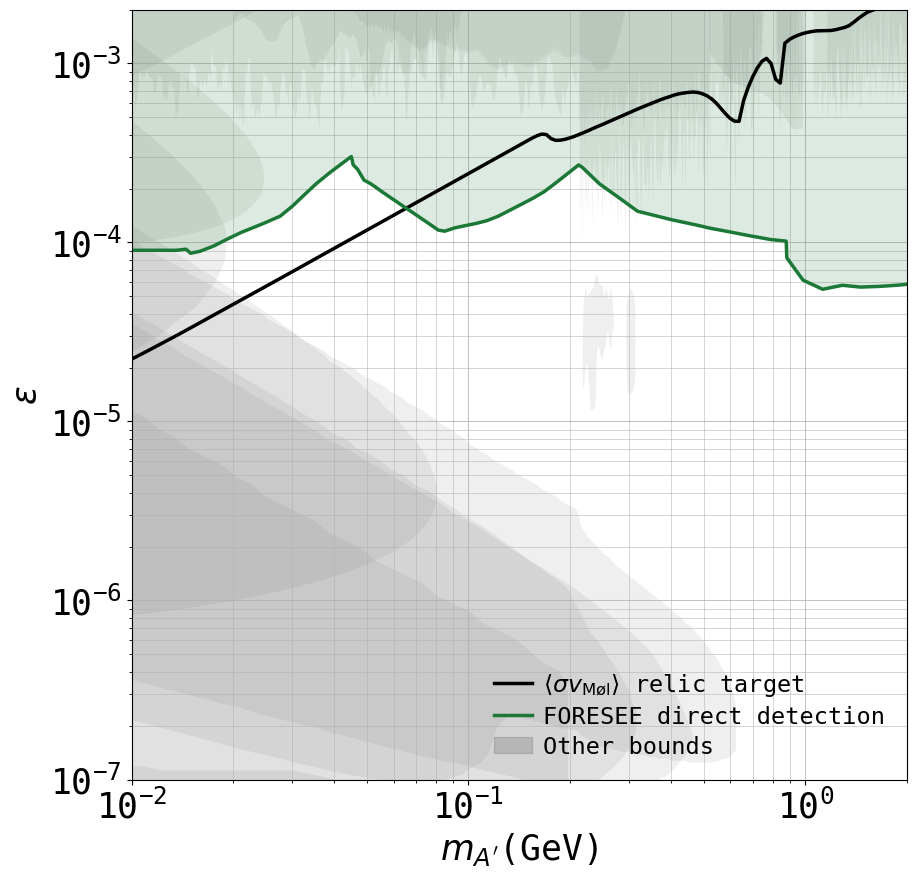

In [15]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

ax.plot(ma_relic_w, eps_relic_w, color = 'black', linewidth = 2.5,
        label = r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ relic target")

ax.plot(mlims, eplims, color = 'red', linewidth = 2.5)

ax.fill_between(mlims, eplims,
                1,
                color='red',
                alpha=0.15,
                zorder=1)

ax.plot(mlims_XENONnT, eplims_XENONnT,
        color = '#2a78d6', linewidth = 2.5)

ax.fill_between(mlims_XENONnT, eplims_XENONnT,
                1,
                color='#2a78d6',
                alpha=0.15,
                zorder=1)

# All sixteen shaded as one grey family: individually they would need
# sixteen legend entries and would bury the direct detection lines, and what
# matters here is only which part of the plane they already cover.
for _name, _b in bounds_lines.items():
    ax.fill(_b[:, 0], _b[:, 1], color = '#7e7e7e', alpha = 0.12,
            linewidth = 0, zorder = 0)

# One proxy handle for the family as a whole.
ax.fill(np.nan, np.nan, color = '#7e7e7e', alpha = 0.35,
        label = r"Other bounds")

ax.plot(ma_DD_kling_line, eps_DD_kling_line,
        color = '#1b7837', linewidth = 2.5, label = r"FORESEE direct detection")

ax.fill(ma_DD_kling, eps_DD_kling,
        color = '#1b7837',
        alpha = 0.15,
        zorder = 1)

## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0,2,1]  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'lower right',           # the lower right of the axes is empty
    ncol = 1,                      # stacked, to keep it narrow
    fontsize = 17,
    labelspacing = 0.3,
    handlelength = 1.6,
    handletextpad = 0.5,
    borderpad = 0.4,
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 2e0

y_min = 1e-7
y_max = 2e-3

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_XENONnT_LZ.pdf", bbox_inches='tight')
plt.show()

## Breaking appart the direct detection line:

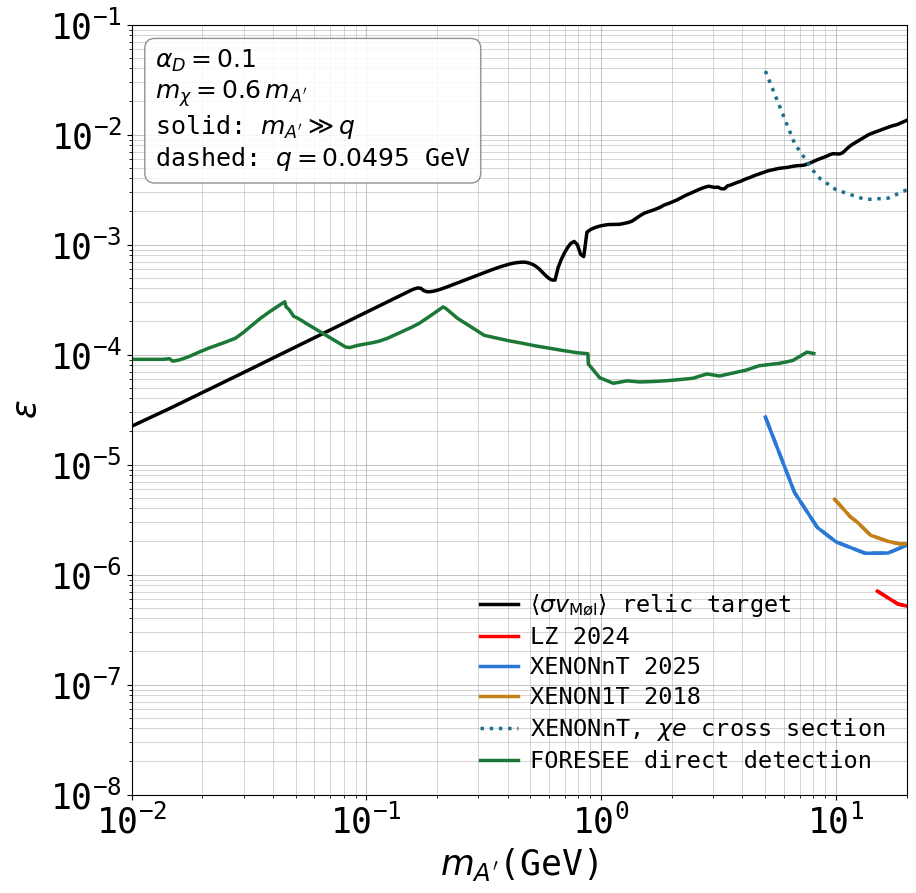

In [16]:
### Plot one of the limits: the same three xenon datasets read against each
### of the three cross sections, so what the reinterpretation itself does is
### visible separately from which experiment supplied the number.

# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

# Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

# Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

# Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

# The relic target the limits are being set against.
ax.plot(ma_relic_w, eps_relic_w, color = 'black', linewidth = 2.5,
        label = r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ relic target")

# Solid is the heavy mediator cross section, dashed the same limit read with
# the mediator form factor kept, and colour says which experiment. The dashed
# curves sit exactly on the solid ones: a xenon nuclear recoil limit only
# exists for mchi >= 3 GeV, i.e. m_A' >= 5 GeV, where q = 49 MeV is four
# orders of magnitude below m_A'^2 in the propagator. The form factor is only
# visible in the cross sections themselves, in the cell below.
ax.plot(mlims, eplims, color = 'red', linewidth = 2.5,
        label = r"LZ 2024")
ax.plot(mlims_ff, eplims_ff, color = 'red', linestyle = '--', linewidth = 2.5)

ax.plot(mlims_XENONnT, eplims_XENONnT, color = '#2a78d6', linewidth = 2.5,
        label = r"XENONnT 2025")
ax.plot(mlims_XENONnT_ff, eplims_XENONnT_ff, color = '#2a78d6',
        linestyle = '--', linewidth = 2.5)

ax.plot(mlims_XENON1T, eplims_XENON1T, color = '#c47f17', linewidth = 2.5,
        label = r"XENON1T 2018")
ax.plot(mlims_XENON1T_ff, eplims_XENON1T_ff, color = '#c47f17',
        linestyle = '--', linewidth = 2.5)

# The electron reading of the same XENONnT number, which is what a nucleon
# limit would become if it were compared against the wrong target: the
# reduced mass drops by (mu_e/mu_p)^2, so epsilon rises by mu_p/mu_e.
ax.plot(mlims_XENONnT_e, eplims_XENONnT_e, color = '#1f6f8b',
        linestyle = ':', linewidth = 2.5,
        label = r"XENONnT, $\chi e$ cross section")

# Kling's contour, for reference.
ax.plot(ma_DD_kling_line, eps_DD_kling_line, color = '#1b7837',
        linewidth = 2.5, label = r"FORESEE direct detection")

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % alphaD,
                   r"$m_\chi = %g\, m_{A'}$" % mchi_over_ma,
                   r"solid: $m_{A'} \gg q$",
                   r"dashed: $q = %.3g$ GeV" % q_ref_n]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'lower right',           # the lower right of the axes is empty
    ncol = 1,                      # stacked, to keep it narrow
    fontsize = 17,
    labelspacing = 0.3,
    handlelength = 1.6,
    handletextpad = 0.5,
    borderpad = 0.4,
    frameon = False                # removes legend border
)

x_min = 1e-2
x_max = 2e1

y_min = 1e-8
y_max = 1e-1

ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/direct_detection_breakdown.pdf", bbox_inches='tight')
plt.show()


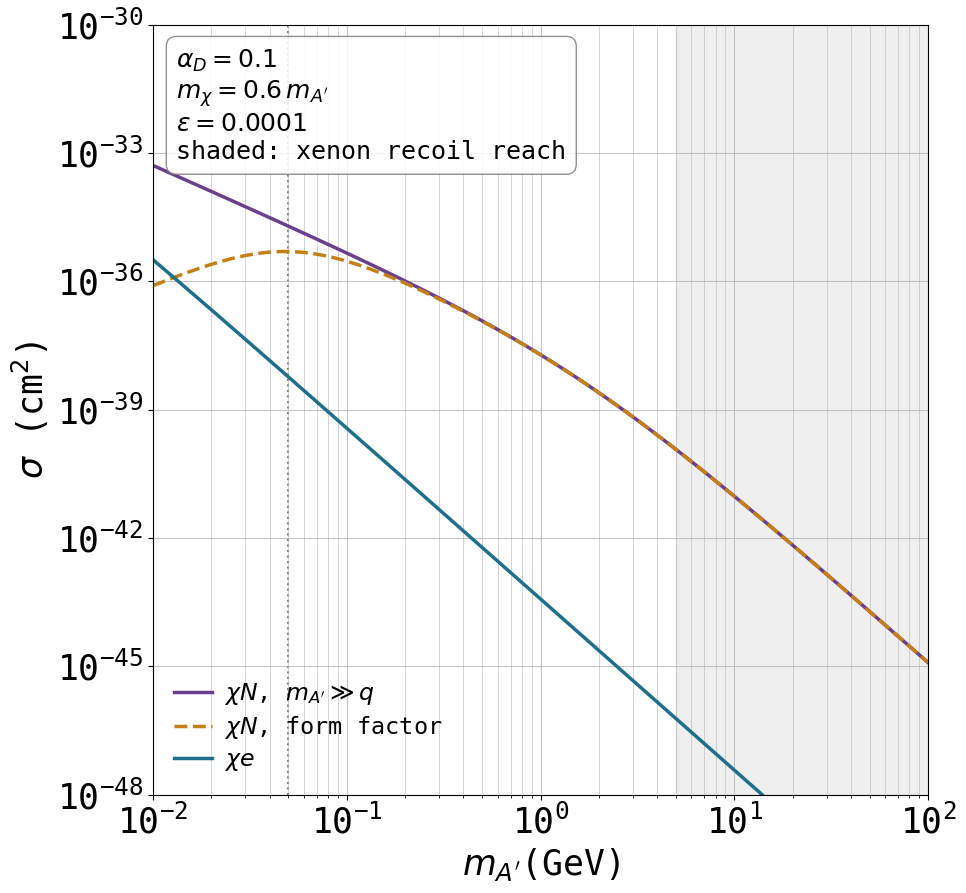

In [17]:
### Where the three cross sections actually differ, at a fixed epsilon: this
### is the piece the limit plot above cannot show, because no xenon nuclear
### recoil limit reaches down to the masses where the propagator matters.

eps_ref = 1e-4

sig_n     = sig_si_theo(ma_dd, alpha, alphaD, mchi_dd, eps_ref)
sig_n_ff  = sig_si_theo_ff(ma_dd, alpha, alphaD, mchi_dd, eps_ref)
sig_e     = sig_si_theo_elec(ma_dd, alpha, alphaD, mchi_dd, eps_ref)

# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\sigma$ (cm$^2$)")

# Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

# Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

# Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

ax.plot(ma_dd, sig_n/cm2_to_GeVm2, color = '#6a408d', linewidth = 2.5,
        label = r"$\chi N$, $m_{A'} \gg q$")
ax.plot(ma_dd, sig_n_ff/cm2_to_GeVm2, color = '#c47f17', linestyle = '--',
        linewidth = 2.5, label = r"$\chi N$, form factor")
ax.plot(ma_dd, sig_e/cm2_to_GeVm2, color = '#1f6f8b', linewidth = 2.5,
        label = r"$\chi e$")

# The momentum transfer the form factor turns over at.
ax.axvline(q_ref_n, color = '#7e7e7e', linestyle = ':', linewidth = 1.5,
           zorder = 0)

# The mass range xenon nuclear recoils actually constrain starts here.
ax.axvspan(mass_data_XENONnT_si.min()/mchi_over_ma, 1e2,
           color = '#7e7e7e', alpha = 0.12, zorder = 0)

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % alphaD,
                   r"$m_\chi = %g\, m_{A'}$" % mchi_over_ma,
                   r"$\varepsilon = %g$" % eps_ref,
                   r"shaded: xenon recoil reach"]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'lower left',
    ncol = 1,
    fontsize = 17,
    labelspacing = 0.3,
    handlelength = 1.6,
    handletextpad = 0.5,
    borderpad = 0.4,
    frameon = False                # removes legend border
)

ax.set_xbound(1e-2, 1e2)

# Chosen to keep the low mass end, where the two nucleon curves separate,
# on the axes rather than the full range of the electron one.
ax.set_ybound(1e-48, 1e-30)

# Save and show the figure:
plt.savefig("figures/direct_detection_cross_sections.pdf", bbox_inches='tight')
plt.show()
